In [72]:
import optgraphstate as ogs
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from optimization_script import run_optimization
import stim
import igraph as ig
import scipy.io

In [73]:
max_n = 11
max_m = 11

cnots_Naive = []
emitters_Naive = []
cnots_Heur1 = []
emitters_Heu1 = []
for n in range(2, max_n+1):
    for m in range(n, max_m+1):
        with open(f'/Users/konstantinosrafailrevis/Desktop/PhD/0paul_state_gen/photonic-graphstate-generator-main/evas_results/results_summary_grid_{n}by{m}.txt', 'r') as file:
            contents = file.read().strip()
            array = eval(contents)
            cnots_Naive.append(array[0])
            emitters_Naive.append(array[1])
            cnots_Heur1.append(array[2])
            emitters_Heu1.append(array[3])
            




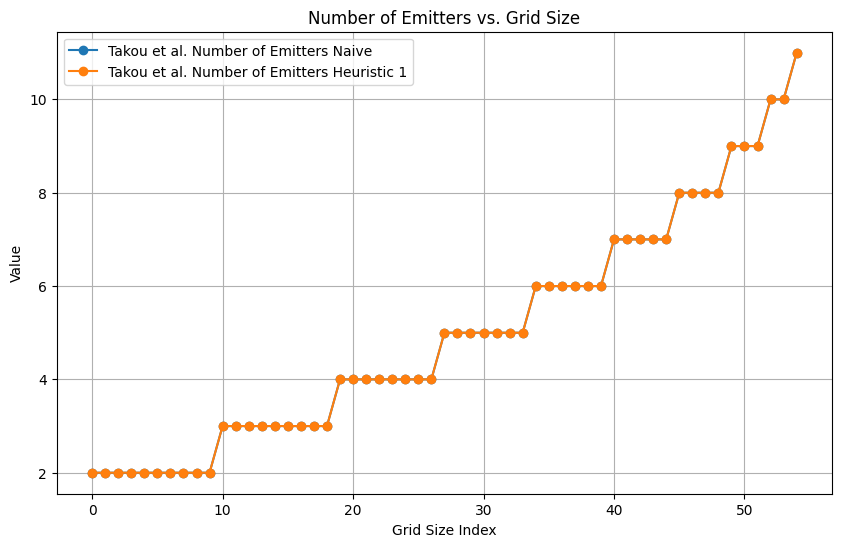

In [74]:
# Create the line plot for emitters_Naive
plt.figure(figsize=(10, 6))
plt.plot(range(len(emitters_Naive)), emitters_Naive, marker='o',label='Takou et al. Number of Emitters Naive')

# Create the line plot for cnots_Naive
plt.plot(range(len(emitters_Heu1)), emitters_Heu1,marker='o' ,label='Takou et al. Number of Emitters Heuristic 1')

# Set the labels
plt.xlabel('Grid Size Index')
plt.ylabel('Value')

# Set the title
plt.title('Number of Emitters vs. Grid Size')

# Add legend
plt.legend()

# Set the y-axis to show only integers
# plt.yticks(range(min(min(emitters_Naive), min(cnots_Naive)), max(max(emitters_Naive), max(cnots_Naive))+1))

# Add a grid to the plot
plt.grid(True)

# Show the plot
plt.show()

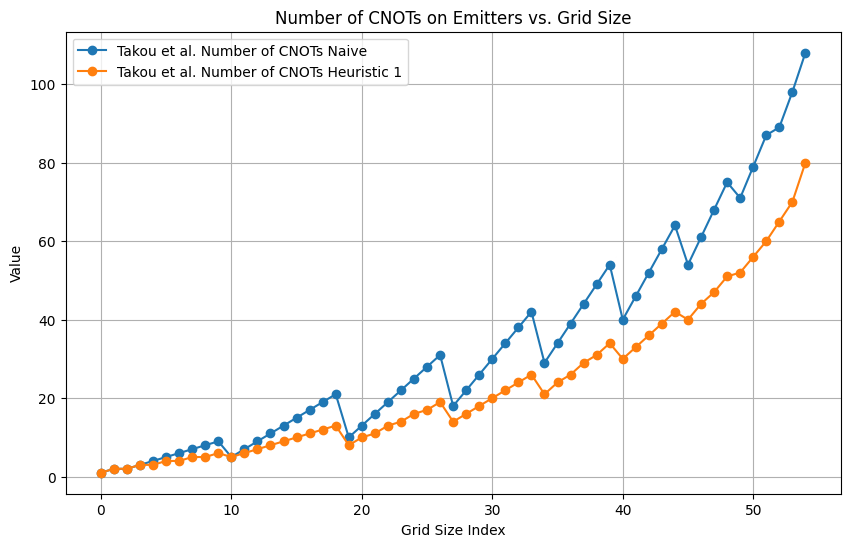

In [75]:
# Create the line plot for emitters_Naive
plt.figure(figsize=(10, 6))
plt.plot(range(len(cnots_Naive)), cnots_Naive, marker='o',label='Takou et al. Number of CNOTs Naive')

# Create the line plot for cnots_Naive
plt.plot(range(len(cnots_Heur1)), cnots_Heur1, marker='o',label='Takou et al. Number of CNOTs Heuristic 1')

# Set the labels
plt.xlabel('Grid Size Index')
plt.ylabel('Value')

# Set the title
plt.title('Number of CNOTs on Emitters vs. Grid Size')

# Add legend
plt.legend()

# Set the y-axis to show only integers
# plt.yticks(range(min(min(emitters_Naive), min(cnots_Naive)), max(max(emitters_Naive), max(cnots_Naive))+1))

# Add a grid to the plot
plt.grid(True)

# Show the plot
plt.show()

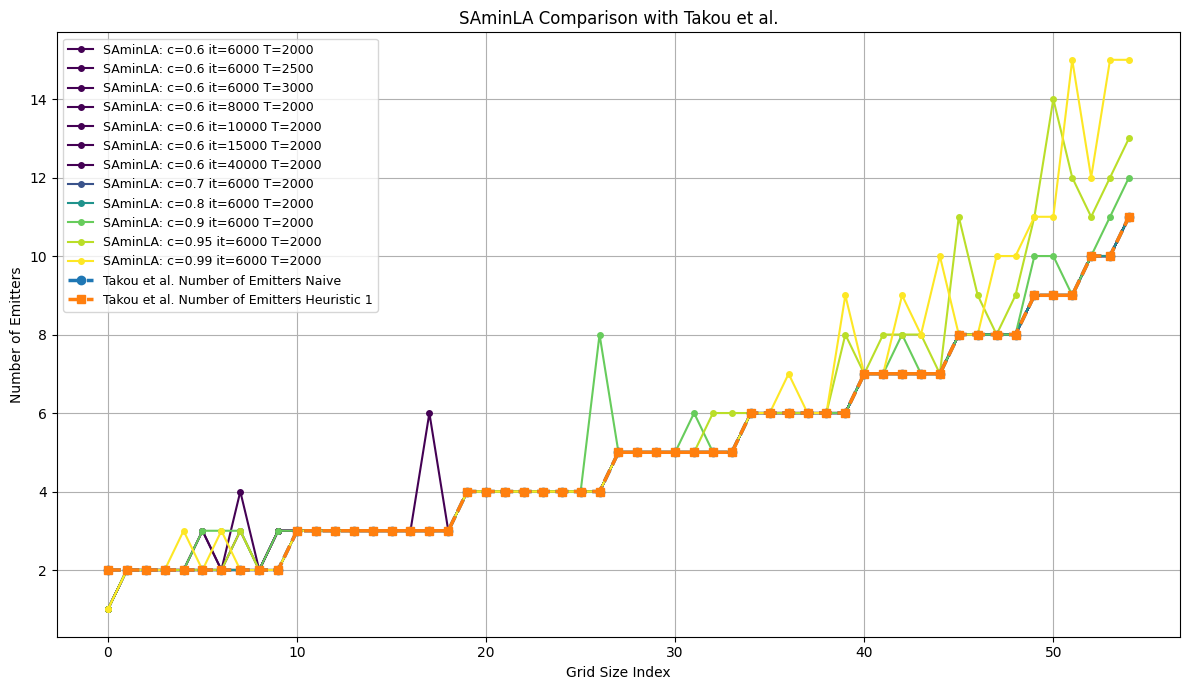

In [76]:
import os
import re
import matplotlib.pyplot as plt
import numpy as np

#SAminLA data
folder = "/Users/konstantinosrafailrevis/Desktop/PhD/0paul_state_gen/photonic-graphstate-generator-main/"

pattern = r"number_of_emitters_cooling([0-9.]+)_iterations(\d+)_temp(\d+)\.txt"

runs = []


#  Load all simulation runs

for fname in os.listdir(folder):
    match = re.match(pattern, fname)
    if match:
        cooling = float(match.group(1))
        iterations = int(match.group(2))
        temp = int(match.group(3))

        filepath = os.path.join(folder, fname)

        with open(filepath, "r") as f:
            data = [float(x.strip()) for x in f if x.strip()]

        runs.append({
            "cooling": cooling,
            "iterations": iterations,
            "temp": temp,
            "data": data,
            "filename": fname
        })


#  Sort by (cooling, iterations)

runs = sorted(runs, key=lambda x: (x["cooling"], x["iterations"]))


#  Colormap based on cooling

coolings = np.array([run["cooling"] for run in runs])
norm = (coolings - coolings.min()) / (coolings.max() - coolings.min() + 1e-12)
cmap = plt.cm.viridis
colors = cmap(norm)


#  Plot everything together

plt.figure(figsize=(12, 7))


for run, color in zip(runs, colors):
    label = f"SAminLA: c={run['cooling']} it={run['iterations']} T={run['temp']}"
    plt.plot(
        run["data"],
        color=color,
        linewidth=1.5,
        marker='o',
        markersize=4,
        label=label
    )


plt.plot(
    range(len(emitters_Naive)),
    emitters_Naive,
    marker='o',
    linestyle='--',
    linewidth=2.5,
    label='Takou et al. Number of Emitters Naive'
)

plt.plot(
    range(len(emitters_Heu1)),
    emitters_Heu1,
    marker='s',
    linestyle='--',
    linewidth=2.5,
    label='Takou et al. Number of Emitters Heuristic 1'
)


#  Labels and layout

plt.xlabel("Grid Size Index")
plt.ylabel("Number of Emitters")
plt.title("SAminLA Comparison with Takou et al.")
plt.grid(True)
plt.legend(loc="best", fontsize=9)
plt.tight_layout()

plt.show()


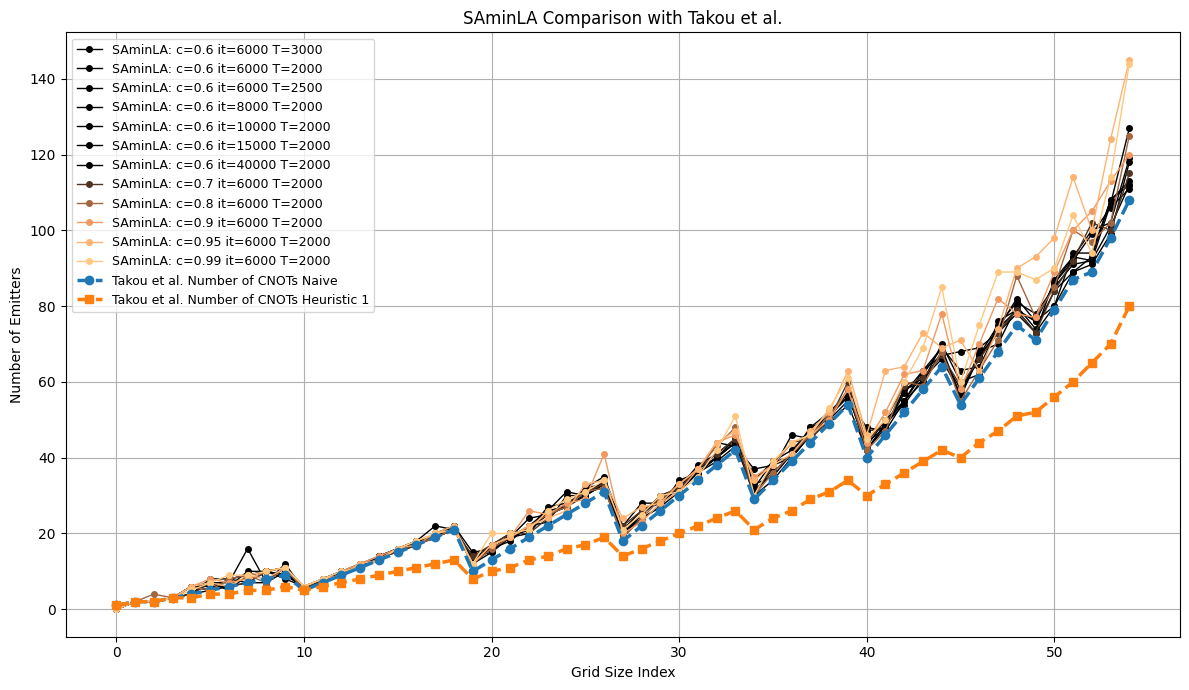

In [77]:
import os
import re
import matplotlib.pyplot as plt
import numpy as np

# SAminLA data
folder = "/Users/konstantinosrafailrevis/Desktop/PhD/0paul_state_gen/photonic-graphstate-generator-main/"
pattern = r"number_of_cnots_cooling([0-9.]+)_iterations(\d+)_temp(\d+)\.txt"

runs = []

# Load all simulation runs
for fname in os.listdir(folder):
    match = re.match(pattern, fname)
    if match:
        cooling = float(match.group(1))
        iterations = int(match.group(2))
        temp = int(match.group(3))

        filepath = os.path.join(folder, fname)
        with open(filepath, "r") as f:
            data = [float(x.strip()) for x in f if x.strip()]

        runs.append({
            "cooling": cooling,
            "iterations": iterations,
            "temp": temp,
            "data": data,
            "filename": fname
        })

# Sort by (cooling, iterations)
runs = sorted(runs, key=lambda x: (x["cooling"], x["iterations"]))

# --- Assign colors to runs ---
# Use a qualitative colormap if few runs, continuous colormap if many
num_runs = len(runs)
if num_runs <= 10:
    cmap = plt.cm.tab10
    colors = cmap(np.arange(num_runs))
else:
    # Continuous colormap based on cooling
    coolings = np.array([run["cooling"] for run in runs])
    norm = (coolings - coolings.min()) / (coolings.max() - coolings.min() + 1e-12)
    cmap = plt.cm.copper
    colors = cmap(norm)

# ----------------------------------------
# PLOT
# ----------------------------------------
plt.figure(figsize=(12, 7))

# SAminLA runs with distinct colors
for run, color in zip(runs, colors):
    label = f"SAminLA: c={run['cooling']} it={run['iterations']} T={run['temp']}"
    plt.plot(
        run["data"],
        color=color,
        linewidth=1.0,
        marker='o',
        markersize=4,
        label=label
    )

# Reference curves (keep colors as before)
plt.plot(
    range(len(cnots_Naive)),
    cnots_Naive,
    marker='o',
    linestyle='--',
    linewidth=2.5,
    label='Takou et al. Number of CNOTs Naive'
)

plt.plot(
    range(len(cnots_Heur1)),
    cnots_Heur1,
    marker='s',
    linestyle='--',
    linewidth=2.5,
    label='Takou et al. Number of CNOTs Heuristic 1'
)

# Labels and layout
plt.xlabel("Grid Size Index")
plt.ylabel("Number of Emitters")
plt.title("SAminLA Comparison with Takou et al.")
plt.grid(True)
plt.legend(loc="best", fontsize=9)
plt.tight_layout()
plt.show()


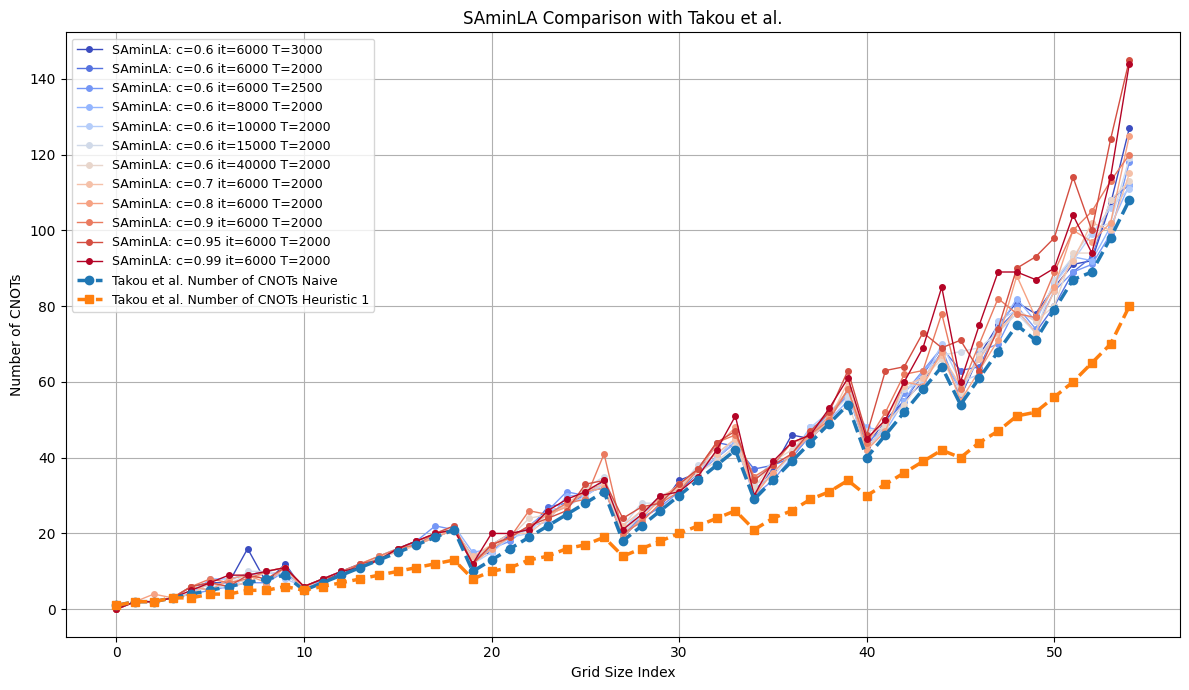

In [78]:
import os
import re
import matplotlib.pyplot as plt
import numpy as np

# SAminLA data folder
folder = "/Users/konstantinosrafailrevis/Desktop/PhD/0paul_state_gen/photonic-graphstate-generator-main/"
pattern = r"number_of_cnots_cooling([0-9.]+)_iterations(\d+)_temp(\d+)\.txt"

runs = []

# Load all simulation runs
for fname in os.listdir(folder):
    match = re.match(pattern, fname)
    if match:
        cooling = float(match.group(1))
        iterations = int(match.group(2))
        temp = int(match.group(3))

        filepath = os.path.join(folder, fname)
        with open(filepath, "r") as f:
            data = [float(x.strip()) for x in f if x.strip()]

        runs.append({
            "cooling": cooling,
            "iterations": iterations,
            "temp": temp,
            "data": data,
            "filename": fname
        })

# Sort by (cooling, iterations) for consistent order
runs = sorted(runs, key=lambda x: (x["cooling"], x["iterations"]))

# Assign unique colors to each run
num_runs = len(runs)
cmap = plt.cm.coolwarm  #<----------------------- Choose any colormap you like
colors = cmap(np.linspace(0, 1, num_runs))  # Evenly spaced colors

# ----------------------------------------
# PLOT
# ----------------------------------------
plt.figure(figsize=(12, 7))

# Plot SAminLA runs with distinct colors
for run, color in zip(runs, colors):
    label = f"SAminLA: c={run['cooling']} it={run['iterations']} T={run['temp']}"
    plt.plot(
        run["data"],
        color=color,
        linewidth=1.0,
        marker='o',
        markersize=4,
        label=label
    )

# Reference curves (keep colors as before)
plt.plot(
    range(len(cnots_Naive)),
    cnots_Naive,
    marker='o',
    linestyle='--',
    linewidth=2.5,
    label='Takou et al. Number of CNOTs Naive'
)

plt.plot(
    range(len(cnots_Heur1)),
    cnots_Heur1,
    marker='s',
    linestyle='--',
    linewidth=2.5,
    label='Takou et al. Number of CNOTs Heuristic 1'
)

# Labels and layout
plt.xlabel("Grid Size Index")
plt.ylabel("Number of CNOTs")
plt.title("SAminLA Comparison with Takou et al.")
plt.grid(True)
plt.legend(loc="best", fontsize=9)
plt.tight_layout()
plt.show()


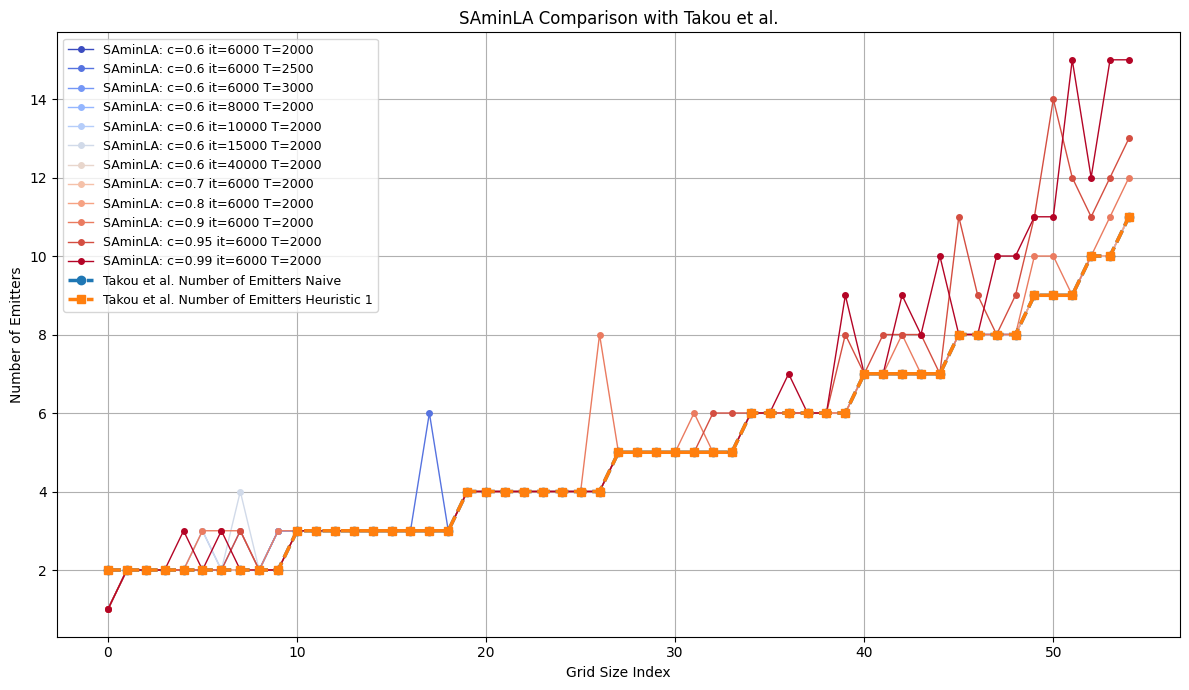

In [79]:
import os
import re
import matplotlib.pyplot as plt
import numpy as np

# SAminLA data folder
folder = "/Users/konstantinosrafailrevis/Desktop/PhD/0paul_state_gen/photonic-graphstate-generator-main/"
pattern = r"number_of_emitters_cooling([0-9.]+)_iterations(\d+)_temp(\d+)\.txt"

runs = []

# Load all simulation runs
for fname in os.listdir(folder):
    match = re.match(pattern, fname)
    if match:
        cooling = float(match.group(1))
        iterations = int(match.group(2))
        temp = int(match.group(3))

        filepath = os.path.join(folder, fname)
        with open(filepath, "r") as f:
            data = [float(x.strip()) for x in f if x.strip()]

        runs.append({
            "cooling": cooling,
            "iterations": iterations,
            "temp": temp,
            "data": data,
            "filename": fname
        })

# Sort by (cooling, iterations) for consistent order
runs = sorted(runs, key=lambda x: (x["cooling"], x["iterations"]))

# Assign unique colors to each run
num_runs = len(runs)
cmap = plt.cm.coolwarm  #<----------------------- Choose any colormap you like
colors = cmap(np.linspace(0, 1, num_runs))  # Evenly spaced colors

# ----------------------------------------
# PLOT
# ----------------------------------------
plt.figure(figsize=(12, 7))

# Plot SAminLA runs with distinct colors
for run, color in zip(runs, colors):
    label = f"SAminLA: c={run['cooling']} it={run['iterations']} T={run['temp']}"
    plt.plot(
        run["data"],
        color=color,
        linewidth=1.0,
        marker='o',
        markersize=4,
        label=label
    )

# Reference curves (keep colors as before)
plt.plot(
    range(len(emitters_Naive)),
    emitters_Naive,
    marker='o',
    linestyle='--',
    linewidth=2.5,
    label='Takou et al. Number of Emitters Naive'
)

plt.plot(
    range(len(emitters_Heu1)),
    emitters_Heu1,
    marker='s',
    linestyle='--',
    linewidth=2.5,
    label='Takou et al. Number of Emitters Heuristic 1'
)

# Labels and layout
plt.xlabel("Grid Size Index")
plt.ylabel("Number of Emitters")
plt.title("SAminLA Comparison with Takou et al.")
plt.grid(True)
plt.legend(loc="best", fontsize=9)
plt.tight_layout()
plt.show()
